In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
import numpy as np
from pyts.classification import TimeSeriesForest

from tqdm.notebook import tqdm

from typing import Literal

%matplotlib inline

# Baseline TimeSeriesForest

In [2]:
from model_evaluation import EvalConfig, EvalModel
from sklearn.pipeline import Pipeline
import numpy as np

pipeline = Pipeline([
    ('TSF', TimeSeriesForest(n_estimators=100, random_state=42))
])

config = EvalConfig(
    train_path="Data/ts_data.csv",
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label"
)

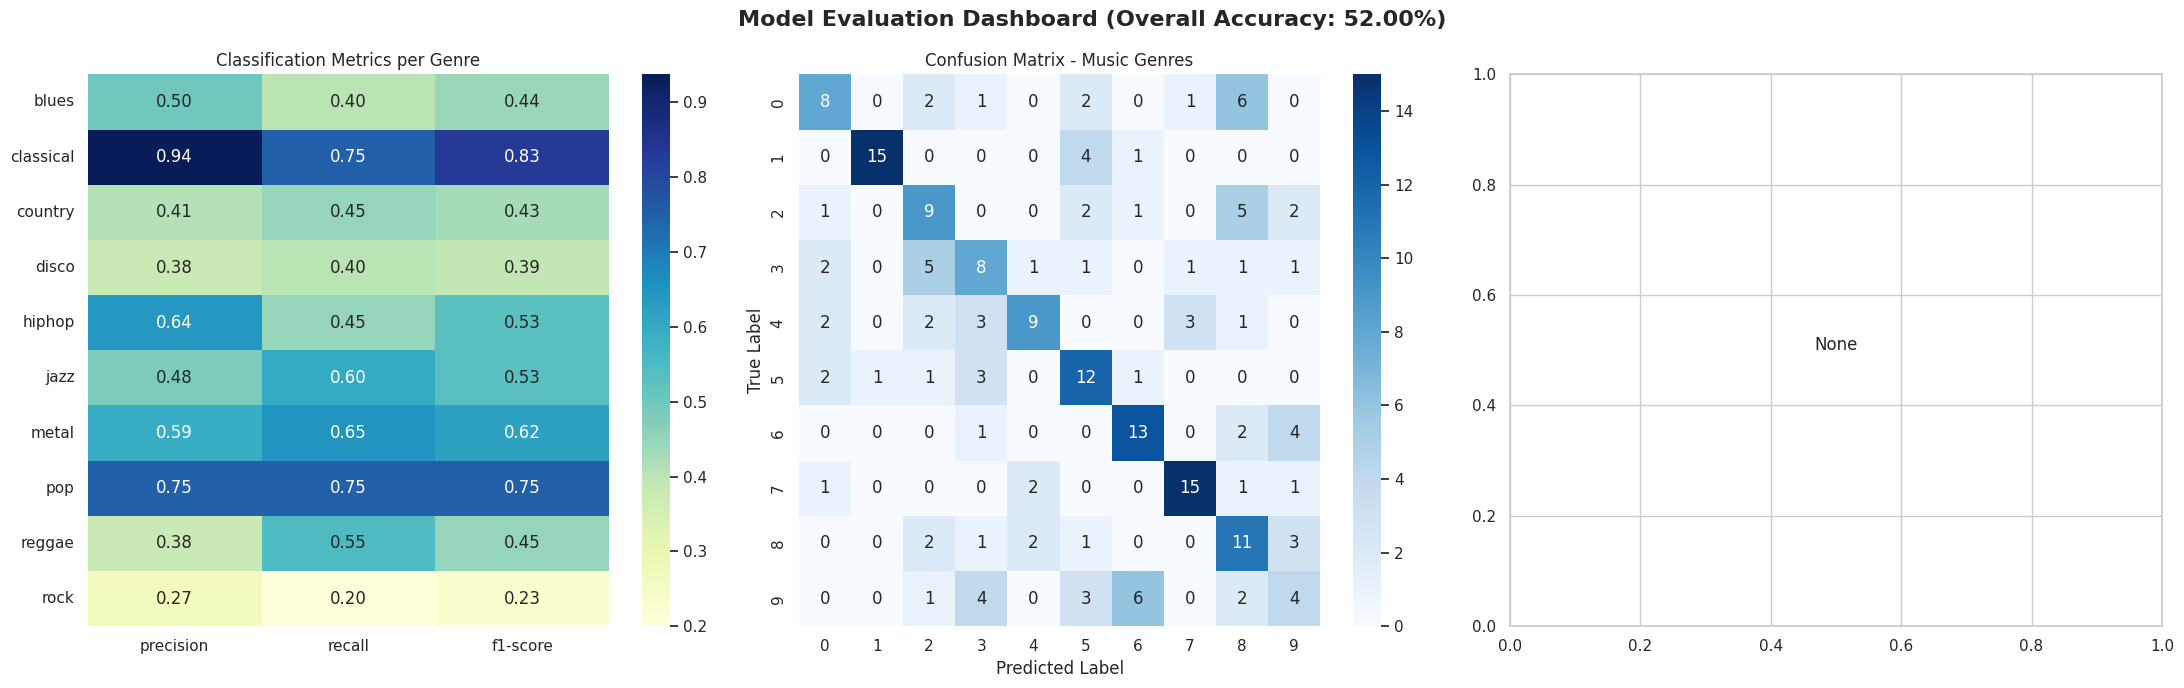

In [3]:
evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()

# Ensemble of a normal model and TSF

1.  wytrenowac RF i TSF
2. zrobic ensemble

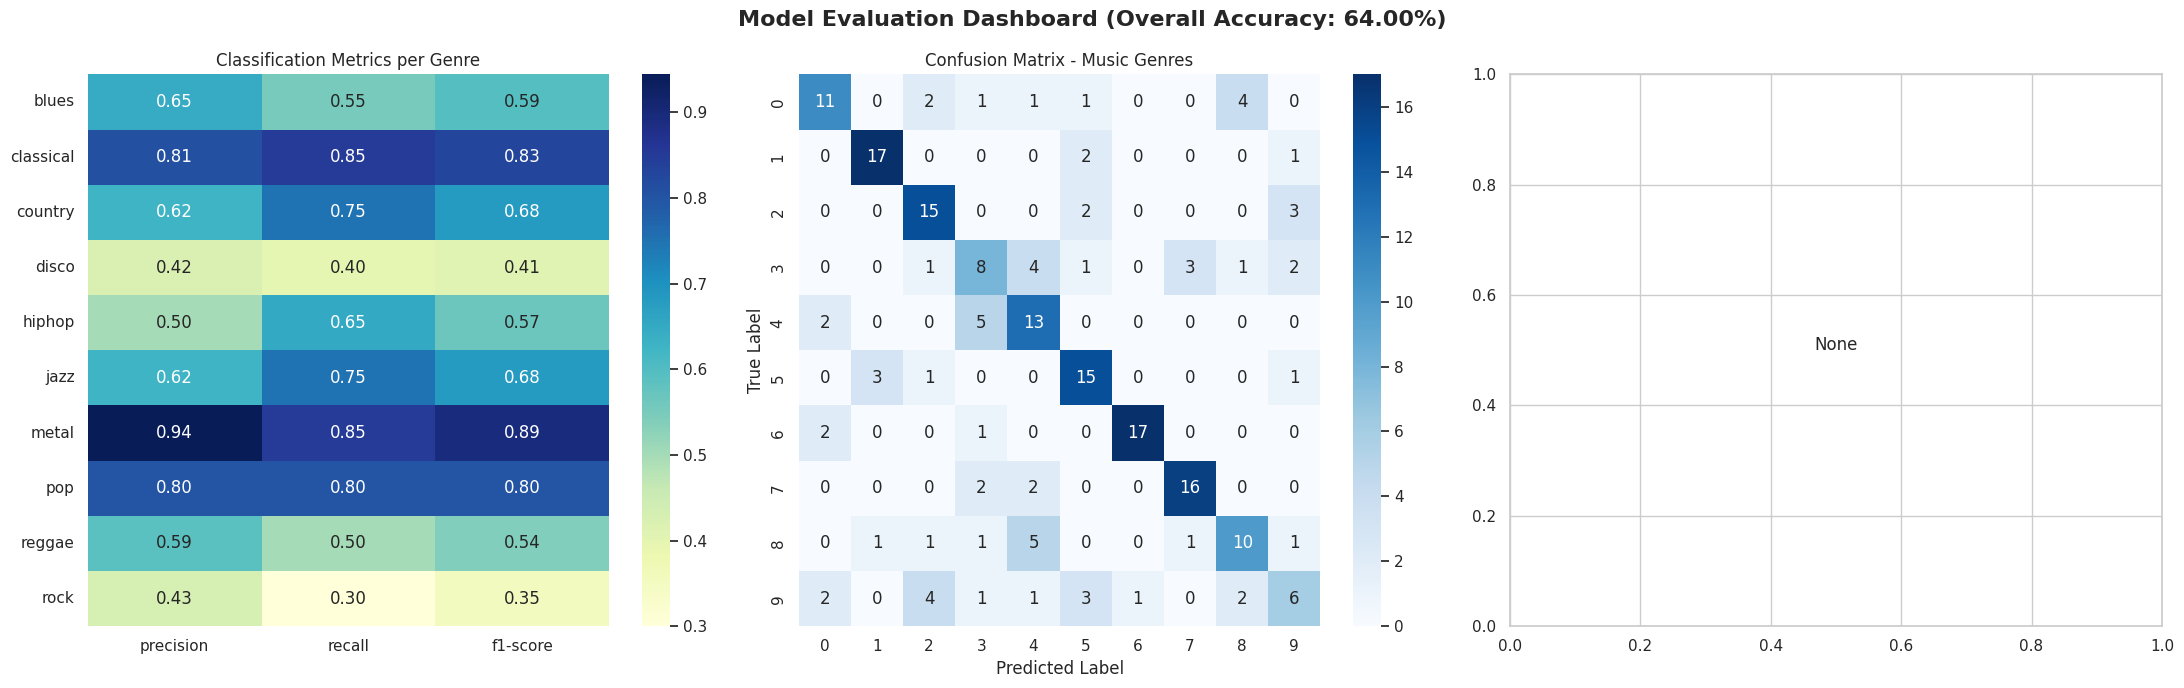

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

from Models.time_series_forest import EnsembleModel

pipeline = Pipeline([
	('clf', EnsembleModel(
        model=RandomForestClassifier(n_estimators=100, random_state=42),
        ts_model=TimeSeriesForest(n_estimators=100, random_state=42),
        w=0.9,
    )),
])

config = EvalConfig(
    train_path="",
    df=pd.read_csv("Data/ts_data.csv"),
    pipeline=pipeline,
    drop_cols=['filename', 'length', 'label'],
    target_col = "label",
    random_state=42,
)

evalModel = EvalModel(config)
res = evalModel.evaluate()
plot = evalModel.plot_eval()